<a href="https://colab.research.google.com/github/fafa20252025/fariba/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
boston=pd.read_csv("Boston.csv")
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
boston.shape

(506, 15)

#Dataset description: input the link of dataset
#Explanatory data analysis: you need to do this

In [ ]:
y=boston["medv"]  #Target variable
x=boston.drop(["medv", "Unnamed: 0"],axis=1) #independent variable, dropping Unnamed: 0 column

In [ ]:
x.shape
y.shape

(506,)

#Train Test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(339, 13)
(167, 13)
(339,)
(167,)


#Model building in Tensorflow (Neural Network)

 3 steps to follow
  1-Model definition
    -Define architecture of the model ( number of layers, number of nodes, Activation functions)

2- Model compilation
    -Optimisation algorithm , learning rate, cost function

3-Training
    -number of iterations (epoch), dataset defining (test,train)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input # Corrected import for Input
from tensorflow.keras.optimizers import Adam

model=Sequential()
model.add(Input(shape=(13,))) # Corrected: Use Input layer and shape as a tuple
model.add(Dense(units=1))   #this is our output layer.

we are going to have 13 wheightage as we have 13 inputs and one bias.

In [ ]:
#Model compilation step

model.compile(optimizer="adam",loss="mean_squared_error")   #loss is know as cost function too
model.compile(optimizer=Adam(learning_rate=0.01),loss="mean_squared_error")

In [ ]:
# Model training step

model.fit(x_train,y_train,epochs=200,validation_data=(x_test,y_test))

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1807.9609 - val_loss: 844.2569
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 716.7076 - val_loss: 291.1656
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 251.9042 - val_loss: 209.6638
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 226.2778 - val_loss: 171.5193
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 164.6981 - val_loss: 128.0376
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 123.9914 - val_loss: 109.2515
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 110.6036 - val_loss: 95.2532
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 109.2962 - val_loss: 84.7335
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 94.1200 - val_loss: 76.5165
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 75.8618 - val_loss: 71.6320
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 84.5006 - val_loss: 65.2768
Epoch 12/200
11/11 ━━━━━

# **Explanation of the training**

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss\: 9688.4258 - val_loss: 9001.4854
*italicised text*

***LOSS: is MSE of training set***
x-train matrix [339*14] * weightage matrix[14*1] = y^-train [339*1]
y^-train [ ]-y-train[ ] =MSE


***Val_loss: is MSE for testing set***
x-test matrix [167*14]* wightage matrix [14*1] =y^-test
y^-test [ ]-y-test[ ]= MSE

In [ ]:
model.history.history

{'loss': [1509.3829345703125,
  590.3478393554688,
  273.5386657714844,
  214.01231384277344,
  164.87672424316406,
  130.8903350830078,
  113.1553726196289,
  102.21662902832031,
  90.6713638305664,
  82.36898803710938,
  84.61351013183594,
  76.99893188476562,
  72.34603118896484,
  66.90687561035156,
  61.79917907714844,
  58.69554901123047,
  57.72236633300781,
  58.90541458129883,
  54.060211181640625,
  55.44925308227539,
  53.33483123779297,
  52.96320343017578,
  56.67190933227539,
  51.01365280151367,
  49.8326530456543,
  49.2459831237793,
  50.945777893066406,
  49.65373229980469,
  49.799102783203125,
  50.61385726928711,
  50.00206756591797,
  47.3664436340332,
  47.67390441894531,
  46.011474609375,
  47.419795989990234,
  45.95491409301758,
  45.495445251464844,
  44.266624450683594,
  48.19450378417969,
  49.227779388427734,
  46.92729187011719,
  48.49515914916992,
  45.00388717651367,
  49.7688102722168,
  46.85148620605469,
  50.433929443359375,
  44.63554382324219,


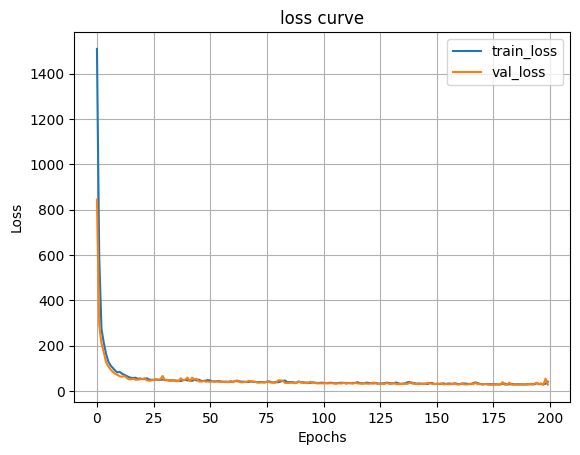

In [ ]:
import matplotlib.pyplot as plt
train_loss=model.history.history["loss"]
val_loss=model.history.history["val_loss"]

plt.plot(train_loss,label="train_loss")
plt.plot(val_loss,label="val_loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("loss curve")
plt.grid()
plt.legend()
plt.show()